In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv('processed_data/merge_data_clustered.csv')

# Pilih fitur z-score untuk clustering
features = ['ir_z_score', 'curah_hujan_z_score', 'kelembapan_z_score', 
            'temperature_z_score', 'kepadatan_penduduk_z_score']
X = df[features].values

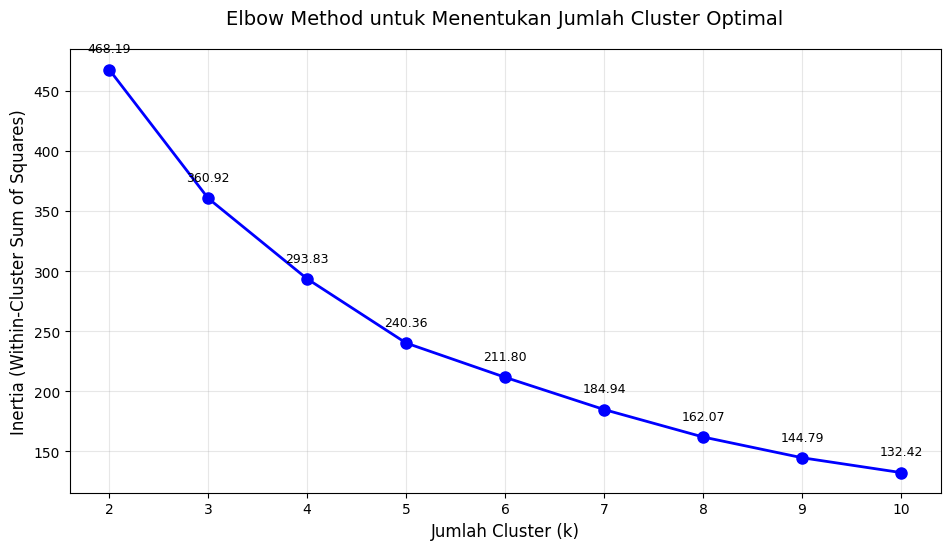

In [8]:
# =============================================
# 1. ELBOW METHOD
# =============================================
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
for i, (k, inertia) in enumerate(zip(K_range, inertias)):
    plt.annotate(f'{inertia:.2f}', (k, inertia), textcoords="offset points", 
                 xytext=(0, 12), ha='center', fontsize=9)
plt.xlabel('Jumlah Cluster (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal', fontsize=14, pad=18)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.subplots_adjust(top=2)
plt.tight_layout(pad=2.5)
plt.show()

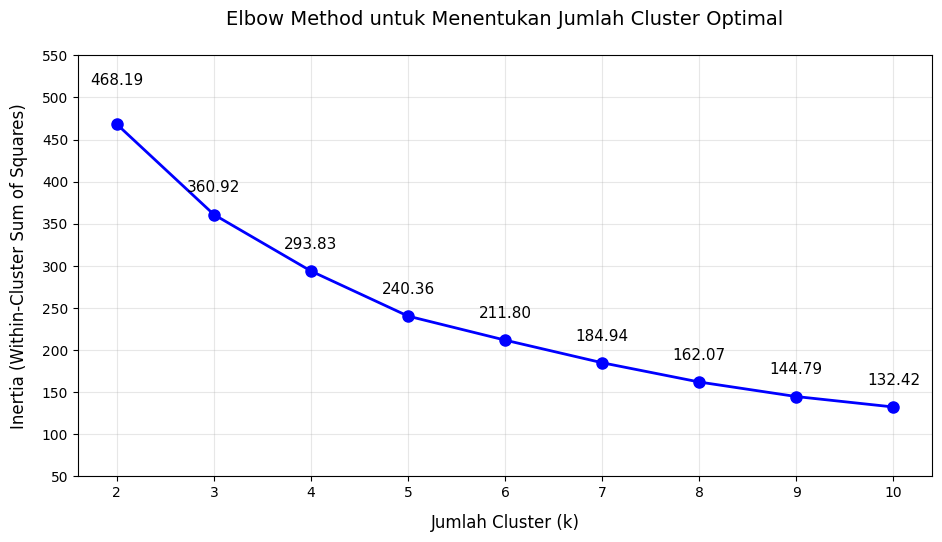

In [7]:
# =============================================
# 1. ELBOW METHOD
# =============================================
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)

# Margin atas & bawah
y_min, y_max = min(inertias), max(inertias)
y_range = y_max - y_min
y_low = y_min - 0.20 * y_range
y_high = y_max + 0.20 * y_range

# Bulatkan batas ke kelipatan 50
y_tick_min = 50 * np.floor(y_low / 50)
y_tick_max = 50 * np.ceil(y_high / 50)

ax.set_ylim(y_tick_min, y_tick_max)
ax.set_yticks(np.arange(y_tick_min, y_tick_max + 1, 50))

for k, inertia in zip(K_range, inertias):
    offset = 26 if inertia == y_max else 14
    ax.annotate(
        f'{inertia:.2f}',
        (k, inertia),
        textcoords="offset points",
        xytext=(0, offset),
        ha='center',
        va='bottom',
        fontsize=11,
        clip_on=False
    )

ax.set_xlabel('Jumlah Cluster (k)', fontsize=12, labelpad=10)
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, labelpad=10)
ax.set_title('Elbow Method untuk Menentukan Jumlah Cluster Optimal', fontsize=14, pad=22)
ax.set_xticks(list(K_range))
ax.grid(True, alpha=0.3)

plt.tight_layout(pad=2.8)
plt.show()

    k      |   Silhouette Score   |
    2      |        0.3431        |
    3      |        0.2662        |
    4      |        0.2937        |
    5      |        0.3231        |
    6      |        0.3275        |
    7      |        0.3194        |
    8      |        0.3227        |
    9      |        0.2984        |
    10     |        0.3111        |

>> Jumlah cluster terbaik: k = 2 (Silhouette Score = 0.3431)


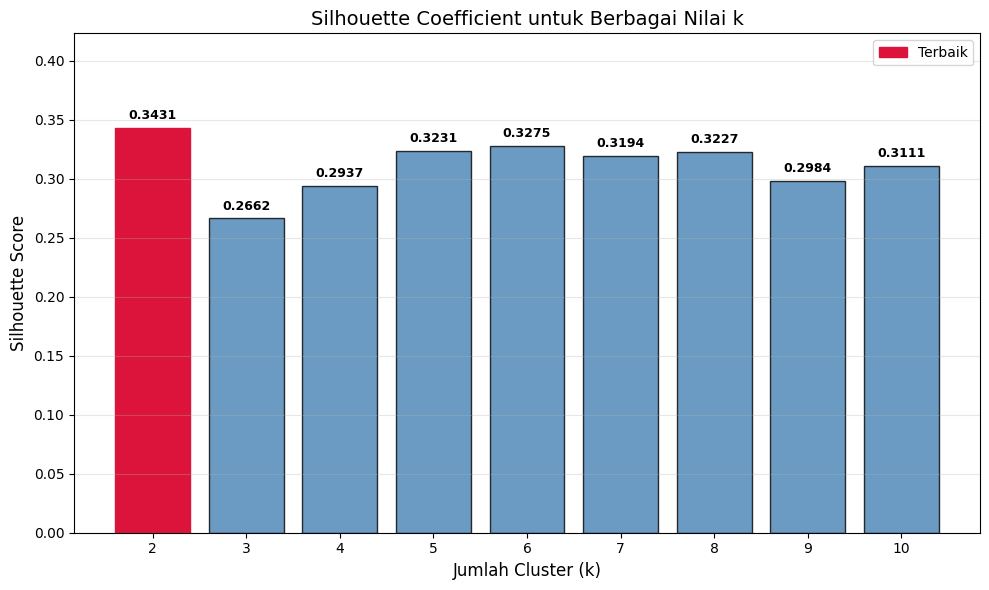

In [3]:
# =============================================
# 2. SILHOUETTE COEFFICIENT
# =============================================
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Tabel Silhouette Score
print('=' * 45)
print(f'{"k":^10} | {"Silhouette Score":^20} |')
print('=' * 45)
for k, score in zip(K_range, silhouette_scores):
    print(f'{k:^10} | {score:^20.4f} |')
print('=' * 45)

best_k = list(K_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
print(f'\n>> Jumlah cluster terbaik: k = {best_k} (Silhouette Score = {best_score:.4f})')

# Plot Silhouette Score
plt.figure(figsize=(10, 6))
bars = plt.bar(K_range, silhouette_scores, color='steelblue', edgecolor='black', alpha=0.8)
# Highlight bar terbaik
best_idx = list(K_range).index(best_k)
bars[best_idx].set_color('crimson')
bars[best_idx].set_alpha(1.0)

for k, score in zip(K_range, silhouette_scores):
    plt.text(k, score + 0.005, f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xlabel('Jumlah Cluster (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Coefficient untuk Berbagai Nilai k', fontsize=14)
plt.xticks(K_range)
plt.ylim(0, max(silhouette_scores) + 0.08)
plt.grid(True, axis='y', alpha=0.3)
plt.legend(['Terbaik'] if best_k else [], loc='upper right')
plt.tight_layout()
plt.show()

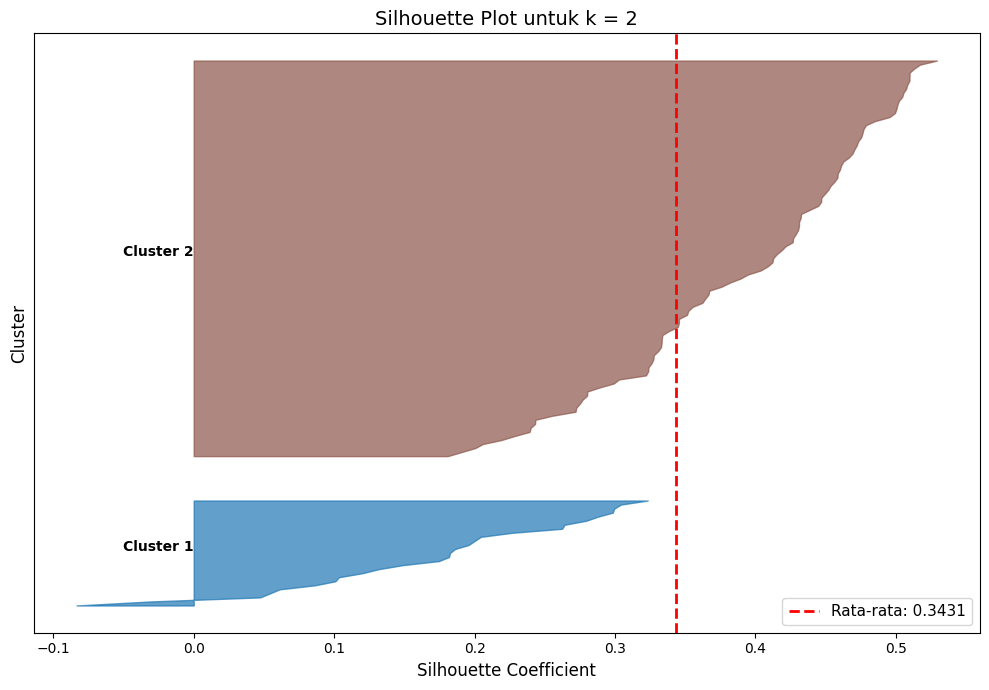

In [ ]:
# ================================================
# 3. SILHOUETTE PLOT PER CLUSTER (untuk k terbaik)
# ================================================
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_best = kmeans_best.fit_predict(X)
silhouette_vals = silhouette_samples(X, labels_best)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(best_k):
    cluster_silhouette_vals = silhouette_vals[labels_best == i]
    cluster_silhouette_vals.sort()
    
    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    
    color = plt.cm.tab10(i / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, f'Cluster {i+1}', fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=best_score, color='red', linestyle='--', linewidth=2, label=f'Rata-rata: {best_score:.4f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot untuk k = {best_k}', fontsize=14)
ax.legend(fontsize=11)
ax.set_yticks([])
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
from scipy.spatial import distance


# 2. Definisikan Kolom yang akan dianalisis
real_cols = ['ir', 'curah_hujan', 'kelembapan', 'temperature', 'kepadatan_penduduk']
z_cols = ['ir_z_score', 'curah_hujan_z_score', 'kelembapan_z_score', 'temperature_z_score', 'kepadatan_penduduk_z_score']

print("=== ANALISIS KARAKTERISTIK KLASTER ===\n")

# 3. Hitung Jumlah Anggota per Klaster
print("1. Jumlah Anggota per Klaster:")
print(df['cluster'].value_counts().sort_index())
print("-" * 50)

# 4. Hitung Nilai Rata-rata Riil (Real Means)
print("\n2. Rata-rata Nilai Asli (Real Mean):")
cluster_real_means = df.groupby('cluster')[real_cols].mean()
print(cluster_real_means.round(2))
print("-" * 50)

# 5. Hitung Nilai Rata-rata Z-Score (Centroid Z-Score)
print("\n3. Rata-rata Z-Score (Penyimpangan dari Normal):")
cluster_z_means = df.groupby('cluster')[z_cols].mean()
print(cluster_z_means.round(2))
print("-" * 50)

# 6. Cari Kecamatan Representatif (Euclidean Distance Terdekat ke Centroid)
print("\n4. Kecamatan Representatif per Klaster:")
for cluster_id in sorted(df['cluster'].unique()):
    # Ambil data khusus klaster ini
    cluster_data = df[df['cluster'] == cluster_id]
    
    # Ambil titik tengah (centroid) klaster ini berdasarkan Z-Score
    centroid = cluster_z_means.loc[cluster_id].values
    
    # Hitung jarak Euclidean setiap kecamatan ke titik centroid
    distances = cluster_data[z_cols].apply(lambda row: distance.euclidean(row.values, centroid), axis=1)
    
    # Cari index dengan jarak paling kecil (paling dekat)
    closest_idx = distances.idxmin()
    rep = df.loc[closest_idx]
    
    # Ambil label kategori risiko (Tinggi/Sedang/Rendah)
    kategori = rep['risk_category']
    
    print(f"Klaster {cluster_id} ({kategori}): {rep['kecamatan']} (Tahun {rep['year']})")
    print(f"   -> IR: {rep['ir']:.2f}, Curah Hujan: {rep['curah_hujan']:.2f}, Suhu: {rep['temperature']:.2f}")

=== ANALISIS KARAKTERISTIK KLASTER ===

1. Jumlah Anggota per Klaster:
cluster
0    47
1    44
2    35
Name: count, dtype: int64
--------------------------------------------------

2. Rata-rata Nilai Asli (Real Mean):
            ir  curah_hujan  kelembapan  temperature  kepadatan_penduduk
cluster                                                                 
0        19.71       273.33       87.75        21.33              949.36
1        63.93       258.77       87.61        21.34             1837.61
2        85.43       247.88       85.57        22.44             1343.54
--------------------------------------------------

3. Rata-rata Z-Score (Penyimpangan dari Normal):
         ir_z_score  curah_hujan_z_score  kelembapan_z_score  \
cluster                                                        
0             -0.43                 0.82                0.77   
1              0.05                -0.90                0.10   
2              0.52                 0.04               -1.16

Gambar berhasil disimpan sebagai 'Gambar_2_Visualisasi_Klaster.png'


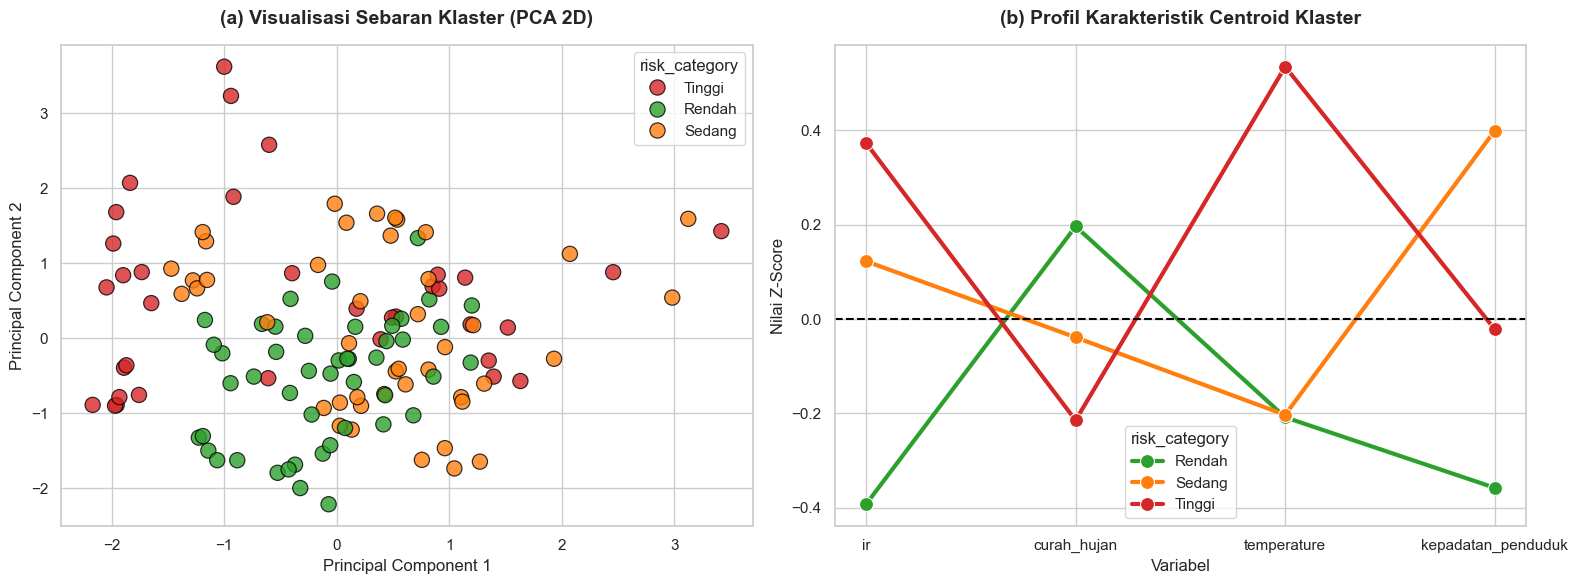

ValueError: Could not interpret value `cluster` for `hue`. An entry with this name does not appear in `data`.

In [10]:
# Sesuaikan nama kolom fitur berdasarkan dataset Anda
# (Hapus atau tambahkan jika ada kolom yang berbeda, misal 'kelembapan')
feature_cols = ['ir', 'curah_hujan', 'temperature', 'kepadatan_penduduk'] 

# Tentukan nama kolom yang berisi hasil klaster Anda
cluster_col = 'risk_category' # Ganti menjadi 'Cluster' jika isinya angka 0,1,2

X = df[feature_cols]

# ==========================================
# 2. NORMALISASI (Z-SCORE) UNTUK VISUALISASI
# ==========================================
# Kita tetap butuh Z-Score untuk membuat grafik PCA dan Profil Garis
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# Masukkan kembali kolom klaster ke dalam data yang sudah di-scale
X_scaled[cluster_col] = df[cluster_col]

# ==========================================
# 3. VISUALISASI (2 PLOT BERDAMPINGAN)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT A (Kiri): Visualisasi PCA Scatter Plot ---
# Reduksi dimensi agar bisa digambar dalam 2D (PC1 & PC2)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled[feature_cols])
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca[cluster_col] = df[cluster_col]

# Atur palet warna. Jika isi kolomnya teks (Rendah, Sedang, Tinggi):
warna_klaster = {'Rendah': '#2ca02c', 'Sedang': '#ff7f0e', 'Tinggi': '#d62728'}
# Catatan: Jika isi kolomnya angka 0, 1, 2, Anda bisa ganti kamus di atas menjadi:
# warna_klaster = {0: '#2ca02c', 1: '#ff7f0e', 2: '#d62728'} (sesuaikan urutan amannya)

# Buat Scatter Plot
sns.scatterplot(
    x='PC1', y='PC2', hue=cluster_col, 
    palette=warna_klaster,
    data=df_pca, ax=axes[0], s=120, alpha=0.8, edgecolor='black'
)
axes[0].set_title('(a) Visualisasi Sebaran Klaster (PCA 2D)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Principal Component 1', fontsize=12)
axes[0].set_ylabel('Principal Component 2', fontsize=12)

# --- PLOT B (Kanan): Profil Karakteristik Centroid (Z-Score) ---
# Hitung rata-rata Z-Score untuk setiap klaster
# Melt data agar mudah di-plot sebagai line chart
cluster_means_melted = X_scaled.groupby(cluster_col).mean().reset_index().melt(id_vars=cluster_col)

# Buat Line Plot
sns.lineplot(
    data=cluster_means_melted, x='variable', y='value', hue=cluster_col, 
    palette=warna_klaster, 
    marker='o', linewidth=3, markersize=10, ax=axes[1]
)
# Garis putus-putus hitam di angka 0 (Rata-rata populasi)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5, label='Rata-rata Keseluruhan (0)')

axes[1].set_title('(b) Profil Karakteristik Centroid Klaster', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Variabel', fontsize=12)
axes[1].set_ylabel('Nilai Z-Score', fontsize=12)

# ==========================================
# 4. PENYIMPANAN
# ==========================================
plt.tight_layout()
plt.savefig('Gambar_2_Visualisasi_Klaster.png', dpi=300, bbox_inches='tight')
print("Gambar berhasil disimpan sebagai 'Gambar_2_Visualisasi_Klaster.png'")

plt.show()

# Buat Line Plot
sns.lineplot(
    data=cluster_means_melted, x='variable', y='value', hue='cluster', 
    palette=['#2ca02c', '#ff7f0e', '#d62728'], 
    marker='o', linewidth=3, markersize=10, ax=axes[1]
)
# Garis putus-putus hitam di angka 0 sebagai penanda batas rata-rata populasi
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5, label='Rata-rata Keseluruhan (0)')

axes[1].set_title('(b) Profil Karakteristik Centroid Klaster', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Variabel', fontsize=12)
axes[1].set_ylabel('Nilai Z-Score', fontsize=12)
# Sesuaikan label sumbu X agar lebih rapi
axes[1].set_xticklabels(['Incident Rate', 'Curah Hujan', 'Kelembapan', 'Suhu', 'Kepadatan'], rotation=15)

# ==========================================
# 4. PENYIMPANAN
# ==========================================
plt.tight_layout()
# Simpan sebagai PNG dengan resolusi tinggi (300 DPI) cocok untuk jurnal
plt.savefig('Gambar_2_Visualisasi_Klaster.png', dpi=300, bbox_inches='tight')
print("Gambar berhasil disimpan sebagai 'Gambar_2_Visualisasi_Klaster.png'")

# Tampilkan plot di layar (jika dijalankan di Jupyter Notebook / IDE)
plt.show()